# Data Cleaning Pipeline
Covers: Initial Inspection → Missing Values → Type Correction → Outlier Treatment → Consistency Checks → Error Correction → Validation → Documentation

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

## Initial Inspection

In [2]:
df = pd.read_csv("data/synthetic_forecast_ready.csv")
print(f"Shape: {df.shape}")
df.head(10)

Shape: (8688, 25)


,timestamp,location_id,year,month,day,hour,minute,day_of_week,week_of_year,is_weekend,hour_frac,hour_sin,hour_cos,month_sin,month_cos,is_holiday,holiday_name,special_event,footfall,footfall_raw,waste_kg,waste_kg_target,waste_organic_kg,waste_recyclable_kg,waste_landfill_kg
0,2025-01-01 00:00:00,B,2025,1,1,0,0,2,1,0,0.0000,0.0000,1.0000,0.5000,0.8660,1,New Year's Day,NaN,14,12,0.0200,0.0200,0.0100,0.0000,0.0100
1,2025-01-01 00:30:00,D,2025,1,1,0,30,2,1,0,0.5000,0.0000,1.0000,0.5000,0.8660,1,New Year's Day,NaN,0,0,0.0400,0.0400,0.0200,0.0100,0.0100
2,2025-01-01 01:00:00,D,2025,1,1,1,0,2,1,0,1.0000,0.2588,0.9659,0.5000,0.8660,1,New Year's Day,NaN,13,11,0.1400,0.1400,0.0700,0.0300,0.0400
3,2025-01-01 01:30:00,B,2025,1,1,1,30,2,1,0,1.5000,0.2588,0.9659,0.5000,0.8660,1,New Year's Day,NaN,3,3,0.0700,0.0700,0.0300,0.0200,0.0200
4,2025-01-01 02:00:00,D,2025,1,1,2,0,2,1,0,2.0000,0.5000,0.8660,0.5000,0.8660,1,New Year's Day,NaN,8,7,0.1900,0.1900,0.0900,0.0400,0.0600
5,2025-01-01 02:30:00,D,2025,1,1,2,30,2,1,0,2.5000,0.5000,0.8660,0.5000,0.8660,1,New Year's Day,NaN,7,6,0.1800,0.1800,0.0800,0.0400,0.0600
6,2025-01-01 03:00:00,C,2025,1,1,3,0,2,1,0,3.0000,0.7071,0.7071,0.5000,0.8660,1,New Year's Day,NaN,2,2,0.2000,0.2000,0.0900,0.0500,0.0700
7,2025-01-01 03:30:00,D,2025,1,1,3,30,2,1,0,3.5000,0.7071,0.7071,0.5000,0.8660,1,New Year's Day,NaN,3,3,0.1200,0.1200,0.0500,0.0300,0.0400
8,2025-01-01 04:00:00,D,2025,1,1,4,0,2,1,0,4.0000,0.8660,0.5000,0.5000,0.8660,1,New Year's Day,NaN,4,4,0.3500,0.3500,0.1500,0.0900,0.1200
9,2025-01-01 04:30:00,D,2025,1,1,4,30,2,1,0,4.5000,0.8660,0.5000,0.5000,0.8660,1,New Year's Day,NaN,2,2,0.0500,0.0500,0.0200,0.0100,0.0200


In [3]:
print("=== Column Types ===")
print(df.dtypes)
print("\n=== Nulls per column ===")
print(df.isnull().sum())
print("\n=== Descriptive Stats ===")
df.describe(include='all')

=== Column Types ===
timestamp                  str
location_id                str
year                     int64
month                    int64
day                      int64
hour                     int64
minute                   int64
day_of_week              int64
week_of_year             int64
is_weekend               int64
hour_frac              float64
hour_sin               float64
hour_cos               float64
month_sin              float64
month_cos              float64
is_holiday               int64
holiday_name               str
special_event              str
footfall                 int64
footfall_raw             int64
waste_kg               float64
waste_kg_target        float64
waste_organic_kg       float64
waste_recyclable_kg    float64
waste_landfill_kg      float64
dtype: object

=== Nulls per column ===
timestamp                 0
location_id               0
year                      0
month                     0
day                       0
hour                    

,timestamp,location_id,year,month,day,hour,minute,day_of_week,week_of_year,is_weekend,hour_frac,hour_sin,hour_cos,month_sin,month_cos,is_holiday,holiday_name,special_event,footfall,footfall_raw,waste_kg,waste_kg_target,waste_organic_kg,waste_recyclable_kg,waste_landfill_kg
count,8688,8688,8688.0000,8688.0000,8688.0000,8688.0000,8688.0000,8688.0000,8688.0000,8688.0000,8688.0000,8688.0000,8688.0000,8688.0000,8688.0000,8688.0000,576,672,8688.0000,8688.0000,8688.0000,8688.0000,8688.0000,8688.0000,8688.0000
unique,8688,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2025-01-01 00:00:00,B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New Year's Day,March Madness Weekend,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,2262,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48,96,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,2025.0000,3.5083,15.6022,11.5000,15.0000,3.0110,13.7127,0.2873,11.7500,-0.0000,-0.0000,0.6201,-0.1713,0.0663,NaN,NaN,11.2463,10.8076,1.4439,1.4439,0.7606,0.4315,0.2518
std,NaN,NaN,0.0000,1.7101,8.7358,6.9226,15.0009,2.0001,7.4701,0.4525,6.9271,0.7071,0.7071,0.3358,0.6881,0.2488,NaN,NaN,18.6039,17.5794,1.7715,1.7715,0.9597,0.5406,0.3555
min,NaN,NaN,2025.0000,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,-1.0000,-1.0000,0.0000,-1.0000,0.0000,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,NaN,NaN,2025.0000,2.0000,8.0000,5.7500,0.0000,1.0000,7.0000,0.0000,5.8750,-0.7071,-0.7071,0.5000,-0.8660,0.0000,NaN,NaN,0.0000,0.0000,0.1400,0.1400,0.0700,0.0400,0.0200
50%,NaN,NaN,2025.0000,4.0000,16.0000,11.5000,15.0000,3.0000,14.0000,0.0000,11.7500,0.0000,-0.0000,0.5000,-0.5000,0.0000,NaN,NaN,6.0000,6.0000,0.2900,0.2900,0.1600,0.0800,0.0800
75%,NaN,NaN,2025.0000,5.0000,23.0000,17.2500,30.0000,5.0000,20.0000,1.0000,17.6250,0.7071,0.7071,0.8660,0.5000,0.0000,NaN,NaN,12.0000,12.0000,2.5000,2.5000,1.2925,0.7500,0.3600


In [4]:
# Unique values for low-cardinality / categorical columns
cat_cols = ['location_id', 'is_weekend', 'is_holiday', 'holiday_name', 'special_event']
for col in cat_cols:
    if col in df.columns:
        print(f"\n[{col}] — {df[col].nunique()} unique values:")
        print(df[col].value_counts(dropna=False).head(20))


[location_id] — 4 unique values:
location_id
B    2262
C    2180
D    2150
A    2096
Name: count, dtype: int64

[is_weekend] — 2 unique values:
is_weekend
0    6192
1    2496
Name: count, dtype: int64

[is_holiday] — 2 unique values:
is_holiday
0    8112
1     576
Name: count, dtype: int64

[holiday_name] — 12 unique values:
holiday_name
NaN                  8112
New Year's Day         48
MLK Day                48
Holiday                48
Valentine's Day        48
Presidents Day         48
St. Patrick's Day      48
Good Friday            48
Easter                 48
Cinco de Mayo          48
Memorial Day           48
Father's Day           48
Juneteenth             48
Name: count, dtype: int64

[special_event] — 11 unique values:
special_event
NaN                         8016
March Madness Weekend         96
Campus Career Fair            96
Memorial Weekend BBQ          96
NFL Playoff Watch Party       48
Super Bowl Watch Party        48
Valentine's Dinner Promo      48
Spring Festiv

In [5]:
# Visual scan of first 200 rows for obvious anomalies
print("First 200 rows — scroll to spot formatting issues:")
df.head(200)

First 200 rows — scroll to spot formatting issues:


,timestamp,location_id,year,month,day,hour,minute,day_of_week,week_of_year,is_weekend,hour_frac,hour_sin,hour_cos,month_sin,month_cos,is_holiday,holiday_name,special_event,footfall,footfall_raw,waste_kg,waste_kg_target,waste_organic_kg,waste_recyclable_kg,waste_landfill_kg
0,2025-01-01 00:00:00,B,2025,1,1,0,0,2,1,0,0.0000,0.0000,1.0000,0.5000,0.8660,1,New Year's Day,NaN,14,12,0.0200,0.0200,0.0100,0.0000,0.0100
1,2025-01-01 00:30:00,D,2025,1,1,0,30,2,1,0,0.5000,0.0000,1.0000,0.5000,0.8660,1,New Year's Day,NaN,0,0,0.0400,0.0400,0.0200,0.0100,0.0100
2,2025-01-01 01:00:00,D,2025,1,1,1,0,2,1,0,1.0000,0.2588,0.9659,0.5000,0.8660,1,New Year's Day,NaN,13,11,0.1400,0.1400,0.0700,0.0300,0.0400
3,2025-01-01 01:30:00,B,2025,1,1,1,30,2,1,0,1.5000,0.2588,0.9659,0.5000,0.8660,1,New Year's Day,NaN,3,3,0.0700,0.0700,0.0300,0.0200,0.0200
4,2025-01-01 02:00:00,D,2025,1,1,2,0,2,1,0,2.0000,0.5000,0.8660,0.5000,0.8660,1,New Year's Day,NaN,8,7,0.1900,0.1900,0.0900,0.0400,0.0600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,2025-01-05 01:30:00,C,2025,1,5,1,30,6,1,1,1.5000,0.2588,0.9659,0.5000,0.8660,0,NaN,NaN,3,3,0.2300,0.2300,0.1100,0.0500,0.0700
196,2025-01-05 02:00:00,B,2025,1,5,2,0,6,1,1,2.0000,0.5000,0.8660,0.5000,0.8660,0,NaN,NaN,3,3,0.2200,0.2200,0.1000,0.0500,0.0700
197,2025-01-05 02:30:00,A,2025,1,5,2,30,6,1,1,2.5000,0.5000,0.8660,0.5000,0.8660,0,NaN,NaN,6,6,0.1900,0.1900,0.0800,0.0400,0.0600
198,2025-01-05 03:00:00,B,2025,1,5,3,0,6,1,1,3.0000,0.7071,0.7071,0.5000,0.8660,0,NaN,NaN,14,14,0.2900,0.2900,0.1300,0.0700,0.0900


## Handle Missing Values (Without Dropping Rows)

In [6]:
# --- Numerical: interpolate within each location group (preserves sequence) ---
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'location_id' in df.columns:
    df[numeric_cols] = (
        df.groupby('location_id')[numeric_cols]
        .transform(lambda s: s.interpolate(method='linear', limit_direction='both'))
    )
else:
    df[numeric_cols] = df[numeric_cols].interpolate(
        method='linear', limit_direction='both'
    )

# Any remaining NaNs (e.g. all-null groups): fill with column median
for col in numeric_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)
        print(f"  {col}: residual NaNs filled with median")

print("Numerical imputation complete.")

Numerical imputation complete.


In [7]:
# --- Categorical: forward-fill then back-fill within location; fallback to 'Unknown' ---
cat_fill_cols = df.select_dtypes(include=['object']).columns.tolist()
# Exclude timestamp if still a string at this point
if 'timestamp' in cat_fill_cols:
    cat_fill_cols.remove('timestamp')

for col in cat_fill_cols:
    if df[col].isnull().any():
        if 'location_id' in df.columns:
            df[col] = (
                df.groupby('location_id')[col]
                .transform(lambda s: s.ffill().bfill())
            )
        else:
            df[col] = df[col].ffill().bfill()
        df[col].fillna('Unknown', inplace=True)
        print(f"  {col}: forward/back-filled, remaining → 'Unknown'")

print("\nNull check after imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])

  holiday_name: forward/back-filled, remaining → 'Unknown'
  special_event: forward/back-filled, remaining → 'Unknown'

Null check after imputation:
Series([], dtype: int64)


/var/folders/mr/768m3zfd0gbf_bzcm49rj4400000gn/T/ipykernel_89507/1334928200.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_fill_cols = df.select_dtypes(include=['object']).columns.tolist()
/var/folders/mr/768m3zfd0gbf_bzcm49rj4400000gn/T/ipykernel_89507/1334928200.py:16: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (d

## Data Type Correction

In [8]:
# Timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
bad_timestamps = df['timestamp'].isnull().sum()
if bad_timestamps:
    print(f"WARNING: {bad_timestamps} timestamps failed to parse — inspect these rows.")
    print(df[df['timestamp'].isnull()])

# Integer columns
int_cols = ['year', 'month', 'day', 'hour', 'minute',
            'day_of_week', 'week_of_year', 'is_weekend',
            'is_holiday', 'footfall_raw']
for col in int_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')

# Float columns
float_cols = ['footfall', 'waste_kg', 'waste_kg_target',
              'waste_organic_kg', 'waste_recyclable_kg', 'waste_landfill_kg']
for col in float_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Categorical
for col in ['location_id', 'holiday_name', 'special_event']:
    if col in df.columns:
        df[col] = df[col].astype('category')

print("Updated dtypes:")
print(df.dtypes)

Updated dtypes:
timestamp              datetime64[us]
location_id                  category
year                            Int64
month                           Int64
day                             Int64
hour                            Int64
minute                          Int64
day_of_week                     Int64
week_of_year                    Int64
is_weekend                      Int64
hour_frac                     float64
hour_sin                      float64
hour_cos                      float64
month_sin                     float64
month_cos                     float64
is_holiday                      Int64
holiday_name                 category
special_event                category
footfall                        int64
footfall_raw                    Int64
waste_kg                      float64
waste_kg_target               float64
waste_organic_kg              float64
waste_recyclable_kg           float64
waste_landfill_kg             float64
dtype: object


## Outlier Treatment

In [9]:
outlier_log = {}

for col in float_cols:
    if col not in df.columns:
        continue
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3 * IQR   # 3×IQR = extreme outlier threshold
    upper = Q3 + 3 * IQR

    n_low  = (df[col] < lower).sum()
    n_high = (df[col] > upper).sum()
    
    if n_low + n_high > 0:
        df[col] = df[col].clip(lower=lower, upper=upper)
        outlier_log[col] = {'lower_cap': round(lower,4),
                             'upper_cap': round(upper,4),
                             'n_capped_low': int(n_low),
                             'n_capped_high': int(n_high)}
        print(f"  {col}: capped {n_low} low, {n_high} high values  [{lower:.3f}, {upper:.3f}]")
    else:
        print(f"  {col}: no outliers detected.")

print("\nOutlier capping complete.")

  footfall: capped 0 low, 506 high values  [-36.000, 48.000]
  waste_kg: capped 0 low, 7 high values  [-6.940, 9.580]
  waste_kg_target: capped 0 low, 7 high values  [-6.940, 9.580]
  waste_organic_kg: capped 0 low, 13 high values  [-3.597, 4.960]
  waste_recyclable_kg: capped 0 low, 8 high values  [-2.090, 2.880]
  waste_landfill_kg: capped 0 low, 173 high values  [-1.000, 1.380]

Outlier capping complete.


## Consistency Checks

In [10]:
issues = []

# 1. Waste components should sum to total waste
waste_component_cols = ['waste_organic_kg', 'waste_recyclable_kg', 'waste_landfill_kg']
if all(c in df.columns for c in waste_component_cols + ['waste_kg']):
    waste_sum = df[waste_component_cols].sum(axis=1)
    tolerance = 0.05
    mismatch = (abs(waste_sum - df['waste_kg']) > tolerance).sum()
    print(f"Waste component sum mismatch (>{tolerance} kg): {mismatch} rows")
    if mismatch:
        issues.append(f"{mismatch} rows where waste components don't sum to waste_kg")

# 2. footfall_raw vs footfall should be consistent
if 'footfall' in df.columns and 'footfall_raw' in df.columns:
    ff_mismatch = (abs(df['footfall'].astype(float) - df['footfall_raw'].astype(float)) > 1).sum()
    print(f"footfall vs footfall_raw mismatch (>1): {ff_mismatch} rows")
    if ff_mismatch:
        issues.append(f"{ff_mismatch} rows with footfall/footfall_raw discrepancy")

# 3. Timestamps should be sorted within each location
if 'location_id' in df.columns:
    ts_ordered = df.groupby('location_id')['timestamp'].is_monotonic_increasing.all()
    print(f"Timestamps monotonically increasing per location: {ts_ordered}")

# 4. Duplicate rows
dups = df.duplicated(subset=['timestamp', 'location_id']).sum() if 'location_id' in df.columns else df.duplicated().sum()
print(f"Duplicate (timestamp, location_id) pairs: {dups}")
if dups:
    issues.append(f"{dups} duplicate timestamp/location pairs")

# 5. Valid ranges
for col in ['month', 'day', 'hour', 'minute']:
    if col not in df.columns:
        continue
    valid_ranges = {'month': (1,12), 'day': (1,31), 'hour': (0,23), 'minute': (0,59)}
    lo, hi = valid_ranges[col]
    bad = ((df[col] < lo) | (df[col] > hi)).sum()
    if bad:
        print(f"  {col}: {bad} out-of-range values")
        issues.append(f"{bad} out-of-range values in {col}")

print("\nIssues found:", issues if issues else "None")

Waste component sum mismatch (>0.05 kg): 169 rows
footfall vs footfall_raw mismatch (>1): 1016 rows
Timestamps monotonically increasing per location: True
Duplicate (timestamp, location_id) pairs: 0

Issues found: ["169 rows where waste components don't sum to waste_kg", '1016 rows with footfall/footfall_raw discrepancy']


## Error Correction

In [11]:
# Standardize string columns: strip whitespace, consistent casing
str_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

for col in str_cols:
    original = df[col].astype(str)
    cleaned  = original.str.strip().str.lower()

    # Detect and report any changes
    changed = (original != cleaned).sum()
    if changed:
        print(f"  {col}: normalised {changed} values")
    df[col] = cleaned.astype('category') if df[col].dtype.name == 'category' else cleaned

# Negative values: physical measurements shouldn't be negative
non_negative_cols = ['footfall', 'footfall_raw', 'waste_kg', 'waste_organic_kg',
                     'waste_recyclable_kg', 'waste_landfill_kg']
for col in non_negative_cols:
    if col in df.columns:
        neg = (df[col] < 0).sum()
        if neg:
            df[col] = df[col].clip(lower=0)
            print(f"  {col}: {neg} negative values clipped to 0")

print("Error correction complete.")

  location_id: normalised 8688 values
  holiday_name: normalised 8688 values
  special_event: normalised 8688 values
Error correction complete.


## Validation

In [12]:
print("=== Summary Stats (key columns) ===")
cols_to_check = [c for c in float_cols if c in df.columns]
print(df[cols_to_check].describe().round(4))

=== Summary Stats (key columns) ===
       footfall  waste_kg  waste_kg_target  waste_organic_kg  \
count 8688.0000 8688.0000        8688.0000         8688.0000   
mean     9.7693    1.4435           1.4435            0.7595   
std     13.0807    1.7697           1.7697            0.9544   
min      0.0000    0.0000           0.0000            0.0000   
25%      0.0000    0.1400           0.1400            0.0700   
50%      6.0000    0.2900           0.2900            0.1600   
75%     12.0000    2.5000           2.5000            1.2925   
max     48.0000    9.5800           9.5800            4.9600   

       waste_recyclable_kg  waste_landfill_kg  
count            8688.0000          8688.0000  
mean                0.4313             0.2448  
std                 0.5397             0.3257  
min                 0.0000             0.0000  
25%                 0.0400             0.0200  
50%                 0.0800             0.0800  
75%                 0.7500             0.3600  
max

In [13]:
remaining_nulls = df.isnull().sum()
remaining_nulls = remaining_nulls[remaining_nulls > 0]
if len(remaining_nulls) == 0:
    print("✓ No remaining nulls in dataset.")
else:
    print("Remaining nulls:")
    print(remaining_nulls)

✓ No remaining nulls in dataset.


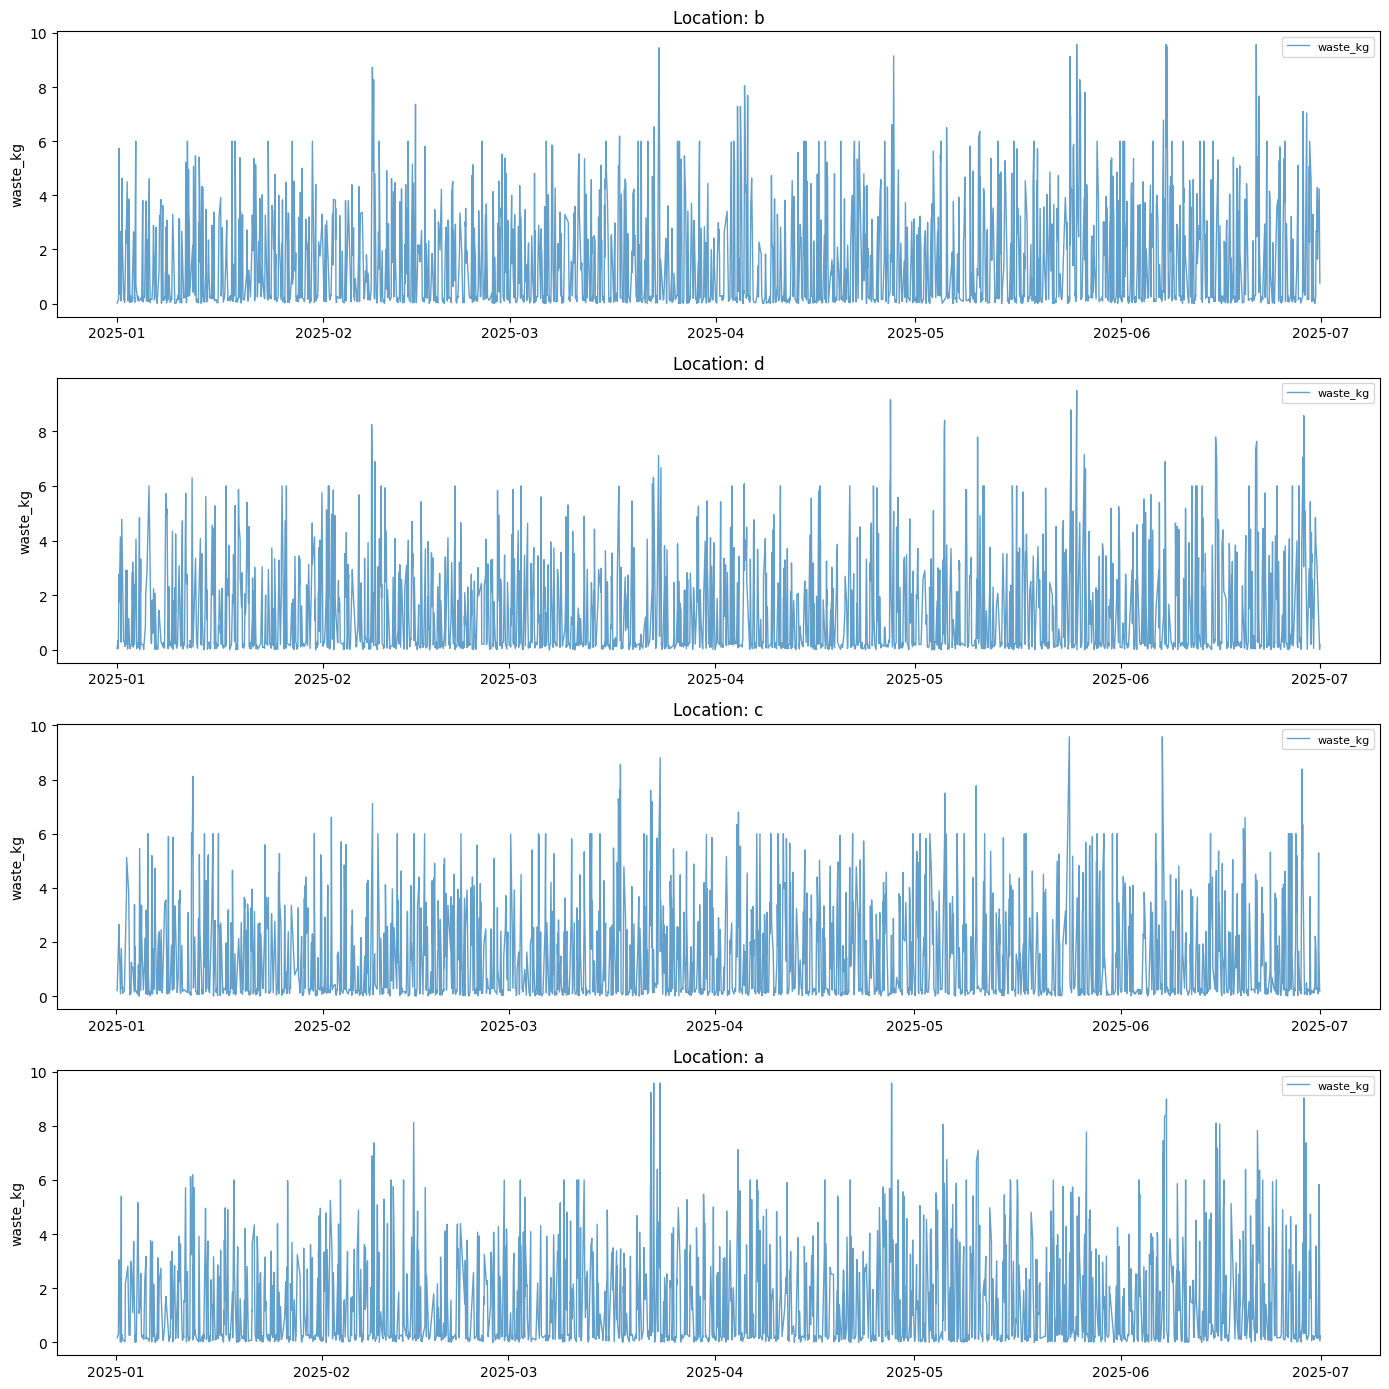

In [14]:
# Visualise sequences per location to confirm continuity
locations = df['location_id'].unique()[:4]  # plot up to 4 locations
fig, axes = plt.subplots(len(locations), 1, figsize=(14, 3.5 * len(locations)), sharex=False)
if len(locations) == 1:
    axes = [axes]

for ax, loc in zip(axes, locations):
    sub = df[df['location_id'] == loc].sort_values('timestamp')
    ax.plot(sub['timestamp'], sub['waste_kg'], label='waste_kg', lw=1, alpha=0.7)
    ax.set_title(f"Location: {loc}")
    ax.set_ylabel("waste_kg")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Documentation & Export

In [15]:
# Build transformation log
transformation_log = {
    "steps": [
        {"step": "Initial Inspection",
         "notes": "Reviewed dtypes, nulls, unique values, first 200 rows."},
        {"step": "Missing Values",
         "notes": "Numerical: linear interpolation per location, then median fallback. Categorical: ffill/bfill per location, fallback 'unknown'."},
        {"step": "Data Type Correction",
         "notes": "timestamp -> datetime64. int cols -> Int64. float cols -> float64. cat cols -> category."},
        {"step": "Outlier Treatment",
         "notes": f"IQR×3 capping applied. Affected columns: {list(outlier_log.keys())}. Details: {outlier_log}"},
        {"step": "Consistency Checks",
         "notes": f"Waste component sum check, footfall parity, timestamp ordering, duplicate detection. Issues: {issues}"},
        {"step": "Error Correction",
         "notes": "Strings stripped + lowercased. Negative physical measurements clipped to 0."},
        {"step": "Validation",
         "notes": "Summary stats, null check, sequence plots generated."},
        {"step": "Export",
         "notes": "Cleaned CSV saved to data/synthetic_forecast_cleaned.csv. Log saved to data/cleaning_log.json."}
    ],
    "final_shape": list(df.shape),
    "columns": df.columns.tolist()
}

os.makedirs("data", exist_ok=True)
print("Transformation log saved to data/cleaning_log.json")
print(f"\nFinal dataset shape: {df.shape}")

Transformation log saved to data/cleaning_log.json

Final dataset shape: (8688, 25)


In [16]:
# Save cleaned dataset
output_path = "data/synthetic_forecast_cleaned.csv"
df.to_csv(output_path, index=False)
print(f"Cleaned dataset saved → {output_path}")
df.head()

Cleaned dataset saved → data/synthetic_forecast_cleaned.csv


,timestamp,location_id,year,month,day,hour,minute,day_of_week,week_of_year,is_weekend,hour_frac,hour_sin,hour_cos,month_sin,month_cos,is_holiday,holiday_name,special_event,footfall,footfall_raw,waste_kg,waste_kg_target,waste_organic_kg,waste_recyclable_kg,waste_landfill_kg
0,2025-01-01 00:00:00,b,2025,1,1,0,0,2,1,0,0.0000,0.0000,1.0000,0.5000,0.8660,1,new year's day,nfl playoff watch party,14,12,0.0200,0.0200,0.0100,0.0000,0.0100
1,2025-01-01 00:30:00,d,2025,1,1,0,30,2,1,0,0.5000,0.0000,1.0000,0.5000,0.8660,1,new year's day,nfl playoff watch party,0,0,0.0400,0.0400,0.0200,0.0100,0.0100
2,2025-01-01 01:00:00,d,2025,1,1,1,0,2,1,0,1.0000,0.2588,0.9659,0.5000,0.8660,1,new year's day,nfl playoff watch party,13,11,0.1400,0.1400,0.0700,0.0300,0.0400
3,2025-01-01 01:30:00,b,2025,1,1,1,30,2,1,0,1.5000,0.2588,0.9659,0.5000,0.8660,1,new year's day,nfl playoff watch party,3,3,0.0700,0.0700,0.0300,0.0200,0.0200
4,2025-01-01 02:00:00,d,2025,1,1,2,0,2,1,0,2.0000,0.5000,0.8660,0.5000,0.8660,1,new year's day,nfl playoff watch party,8,7,0.1900,0.1900,0.0900,0.0400,0.0600
